# TI3145TU Midterm – Adapted for Radiomics (Lipo)

This notebook adapts the original *football wages regression* template to a **binary classification** task using `Lipo_radiomicFeatures.csv`.

Target: `label` (lipoma vs liposarcoma).

## Imports

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import matplotlib.pyplot as plt

## Load data

In [2]:
# Path to your radiomics file
data_path = "Lipo_radiomicFeatures.csv"

data = pd.read_csv(data_path)
print(f"Loaded: {data.shape[0]} rows × {data.shape[1]} columns")
display(data.head())

Loaded: 115 rows × 495 columns


,ID,label,PREDICT_original_sf_compactness_avg_2.5D,PREDICT_original_sf_compactness_std_2.5D,PREDICT_original_sf_rad_dist_avg_2.5D,PREDICT_original_sf_rad_dist_std_2.5D,PREDICT_original_sf_roughness_avg_2.5D,PREDICT_original_sf_roughness_std_2.5D,PREDICT_original_sf_convexity_avg_2.5D,PREDICT_original_sf_convexity_std_2.5D,...,PREDICT_original_phasef_phasesym_median_WL3_N5,PREDICT_original_phasef_phasesym_std_WL3_N5,PREDICT_original_phasef_phasesym_skewness_WL3_N5,PREDICT_original_phasef_phasesym_kurtosis_WL3_N5,PREDICT_original_phasef_phasesym_peak_WL3_N5,PREDICT_original_phasef_phasesym_peak_position_WL3_N5,PREDICT_original_phasef_phasesym_range_WL3_N5,PREDICT_original_phasef_phasesym_energy_WL3_N5,PREDICT_original_phasef_phasesym_quartile_range_WL3_N5,PREDICT_original_phasef_phasesym_entropy_WL3_N5
0,Lipo-001_0,liposarcoma,0.368434,0.262371,26.200395,8.174390,20.940000,13.551937,0.694139,0.227848,...,0.049726,0.196019,0.927821,-0.407270,0.0,0,0.625304,3238.304991,0.315148,14.462361
1,Lipo-002_0,liposarcoma,0.660571,0.179013,55.155046,9.318741,9.546044,7.051937,0.871182,0.125279,...,0.036186,0.167471,1.137972,0.411968,0.0,0,0.563659,15364.724390,0.251255,17.170274
2,Lipo-003_0,lipoma,0.365191,0.157712,30.577026,8.963647,17.695139,10.772365,0.704710,0.137529,...,0.128167,0.220546,0.829650,-0.520344,0.0,0,0.705679,3771.798158,0.369366,14.394812
3,Lipo-004_0,liposarcoma,0.372210,0.169761,94.006805,33.512409,21.049148,15.928362,0.754497,0.186559,...,0.000000,0.107987,3.130011,10.399652,0.0,0,0.438399,4707.658397,0.000000,15.733482
4,Lipo-005_0,lipoma,0.369120,0.167485,94.612701,31.250821,17.059573,15.239905,0.774545,0.192922,...,0.000000,0.087662,3.284943,11.840826,0.0,0,0.356330,6171.440113,0.000000,16.682154


## Quick sanity checks

In [3]:
# Basic schema check
print(data.dtypes.value_counts())
print("\nTarget distribution:")
print(data["label"].value_counts())

# Missingness check (top 15 columns with most missing)
missing = data.isna().sum().sort_values(ascending=False)
display(missing.head(15))

float64    468
int64       25
str          2
Name: count, dtype: int64

Target distribution:
label
liposarcoma    58
lipoma         57
Name: count, dtype: int64


ID                                                     0
PREDICT_original_tf_Gabor_max_F0.2_A1.57               0
PREDICT_original_tf_Gabor_entropy_F0.2_A0.79           0
PREDICT_original_tf_Gabor_quartile_range_F0.2_A0.79    0
PREDICT_original_tf_Gabor_energy_F0.2_A0.79            0
PREDICT_original_tf_Gabor_range_F0.2_A0.79             0
PREDICT_original_tf_Gabor_peak_position_F0.2_A0.79     0
PREDICT_original_tf_Gabor_peak_F0.2_A0.79              0
PREDICT_original_tf_Gabor_kurtosis_F0.2_A0.79          0
PREDICT_original_tf_Gabor_skewness_F0.2_A0.79          0
PREDICT_original_tf_Gabor_std_F0.2_A0.79               0
PREDICT_original_tf_Gabor_median_F0.2_A0.79            0
PREDICT_original_tf_Gabor_mean_F0.2_A0.79              0
PREDICT_original_tf_Gabor_max_F0.2_A0.79               0
PREDICT_original_tf_Gabor_min_F0.2_A0.79               0
dtype: int64

## Define features and target

In [4]:
# 1) Separate target
y_raw = data["label"].astype(str)

# 2) Drop obvious non-features
# - ID is an identifier (keep only if you have a reason to use it; usually you should drop it)
X = data.drop(columns=["label", "ID"], errors="ignore")

# 3) Encode labels to 0/1 (lipoma / liposarcoma)
# NOTE: this mapping is deterministic and printed so you can report it.
classes = sorted(y_raw.unique())
class_to_int = {c:i for i,c in enumerate(classes)}
y = y_raw.map(class_to_int).astype(int)

print("Label mapping:", class_to_int)
print("X shape:", X.shape, "| y shape:", y.shape)

Label mapping: {'lipoma': 0, 'liposarcoma': 1}
X shape: (115, 493) | y shape: (115,)


## Train/test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (92, 493)  Test: (23, 493)


## Preprocessing pipeline

In [6]:
# Split features by type
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

numeric_processor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_processor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_processor, numeric_features),
        ("cat", categorical_processor, categorical_features),
    ],
    remainder="drop"
)

Numeric features: 493
Categorical features: 0


## Baseline model

Accuracy: 0.4782608695652174
Balanced accuracy: 0.5
F1: 0.0


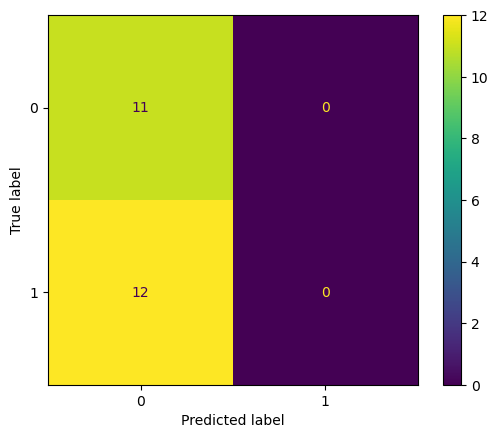

In [7]:
baseline = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", DummyClassifier(strategy="most_frequent", random_state=42))
])

baseline.fit(X_train, y_train)
pred = baseline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, pred))
print("F1:", f1_score(y_test, pred))
ConfusionMatrixDisplay.from_predictions(y_test, pred)
plt.show()

## Candidate models (Pipeline 1: no PCA)

In [8]:
models = {
    "LogReg": LogisticRegression(max_iter=5000, class_weight="balanced", solver="saga"),
    "KNN": KNeighborsClassifier(),
    "RandomForest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "SVC(RBF)": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42),
}

def eval_pipeline(pipe, X_test, y_test):
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else None

    out = {
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba) if proba is not None else np.nan
    }
    return out

scores = {}
for name, clf in models.items():
    pipe = Pipeline(steps=[("prep", preprocessor), ("clf", clf)])
    pipe.fit(X_train, y_train)
    scores[name] = eval_pipeline(pipe, X_test, y_test)

pd.DataFrame(scores).T.sort_values("roc_auc", ascending=False)

,accuracy,balanced_accuracy,f1,roc_auc
RandomForest,0.869565,0.867424,0.880000,0.912879
SVC(RBF),0.739130,0.742424,0.727273,0.818182
LogReg,0.695652,0.696970,0.695652,0.772727
KNN,0.608696,0.613636,0.571429,0.632576


## Pipeline 2: add PCA (optional, mainly useful for linear models)

In [9]:
pca = PCA(n_components=0.95, random_state=42)

scores_pca = {}
for name, clf in models.items():
    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("pca", pca),
        ("clf", clf)
    ])
    pipe.fit(X_train, y_train)
    scores_pca[name] = eval_pipeline(pipe, X_test, y_test)

pd.DataFrame(scores_pca).T.sort_values("roc_auc", ascending=False)

,accuracy,balanced_accuracy,f1,roc_auc
RandomForest,0.782609,0.784091,0.782609,0.878788
LogReg,0.739130,0.742424,0.727273,0.848485
SVC(RBF),0.739130,0.738636,0.750000,0.833333
KNN,0.695652,0.704545,0.631579,0.712121


## Hyperparameter tuning (GridSearchCV)

In [12]:
# Pick one or two models to tune. With 115 samples, keep grids small to avoid overfitting.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grids = {
    "LogReg": {
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__penalty": ["l2", "l1"],
    },
    "RandomForest": {
        "clf__n_estimators": [200, 500],
        "clf__max_depth": [None, 5, 10],
        "clf__min_samples_split": [2, 5],
    },
    "SVC(RBF)": {
        "clf__C": [0.1, 1, 10],
        "clf__gamma": ["scale", 0.01, 0.1],
    }
}

tuned = {}
for name, grid in param_grids.items():
    clf = models[name]
    print(name, type(clf), clf)
    pipe = Pipeline(steps=[("prep", preprocessor), ("clf", clf)])

    gs = GridSearchCV(
        pipe, grid, scoring="roc_auc", cv=cv, n_jobs=-1, refit=True
    )
    gs.fit(X_train, y_train)

    best_pipe = gs.best_estimator_
    tuned[name] = {
        "best_params": gs.best_params_,
        "cv_best_roc_auc": gs.best_score_,
        "test_metrics": eval_pipeline(best_pipe, X_test, y_test),
        "best_estimator": best_pipe
    }

tuned_summary = pd.DataFrame({
    k: {
        **v["test_metrics"],
        "cv_best_roc_auc": v["cv_best_roc_auc"]
    } for k,v in tuned.items()
}).T

display(tuned_summary.sort_values("roc_auc", ascending=False))
tuned

LogReg <class 'sklearn.linear_model._logistic.LogisticRegression'> LogisticRegression(class_weight='balanced', max_iter=5000, solver='saga')


/Users/vincentblendea/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/vincentblendea/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/vincentblendea/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be

RandomForest <class 'sklearn.ensemble._forest.RandomForestClassifier'> RandomForestClassifier(class_weight='balanced', random_state=42)
SVC(RBF) <class 'sklearn.svm._classes.SVC'> SVC(class_weight='balanced', probability=True, random_state=42)


,accuracy,balanced_accuracy,f1,roc_auc,cv_best_roc_auc
LogReg,0.956522,0.958333,0.956522,0.984848,0.690864
RandomForest,0.913043,0.912879,0.916667,0.962121,0.670370
SVC(RBF),0.739130,0.742424,0.727273,0.818182,0.600247


{'LogReg': {'best_params': {'clf__C': 0.1, 'clf__penalty': 'l1'},
  'cv_best_roc_auc': np.float64(0.6908641975308643),
  'test_metrics': {'accuracy': 0.9565217391304348,
   'balanced_accuracy': 0.9583333333333333,
   'f1': 0.9565217391304348,
   'roc_auc': 0.9848484848484848},
  'best_estimator': Pipeline(steps=[('prep',
                   ColumnTransformer(transformers=[('num',
                                                    Pipeline(steps=[('imputer',
                                                                     SimpleImputer(strategy='median')),
                                                                    ('scaler',
                                                                     StandardScaler())]),
                                                    ['PREDICT_original_sf_compactness_avg_2.5D',
                                                     'PREDICT_original_sf_compactness_std_2.5D',
                                                     'PREDICT_original_

## Final model report

Best model: LogReg
Best params: {'clf__C': 0.1, 'clf__penalty': 'l1'}

Test metrics:
{'accuracy': 0.9565217391304348, 'balanced_accuracy': 0.9583333333333333, 'f1': 0.9565217391304348, 'roc_auc': 0.9848484848484848}

Classification report:
              precision    recall  f1-score   support

      lipoma       0.92      1.00      0.96        11
 liposarcoma       1.00      0.92      0.96        12

    accuracy                           0.96        23
   macro avg       0.96      0.96      0.96        23
weighted avg       0.96      0.96      0.96        23



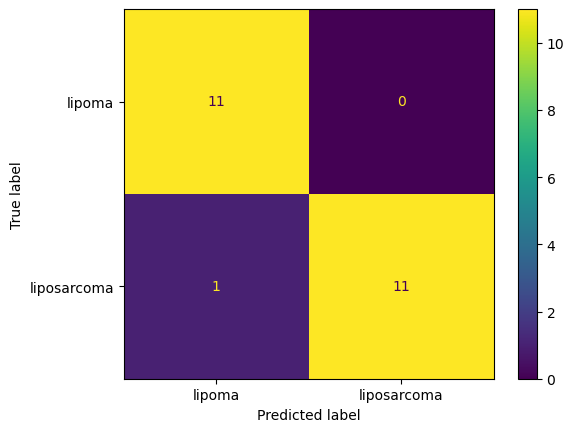

In [11]:
# Choose the best tuned model by TEST ROC-AUC (or by CV if you prefer).
best_name = max(tuned.keys(), key=lambda k: tuned[k]["test_metrics"]["roc_auc"])
best_model = tuned[best_name]["best_estimator"]

print("Best model:", best_name)
print("Best params:", tuned[best_name]["best_params"])

pred = best_model.predict(X_test)
proba = best_model.predict_proba(X_test)[:, 1]

print("\nTest metrics:")
print(eval_pipeline(best_model, X_test, y_test))

print("\nClassification report:")
print(classification_report(y_test, pred, target_names=classes))

ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=classes)
plt.show()

## Is the original template relevant?

- The original notebook is a **regression** workflow (predicting a continuous value, evaluated with **MAE**).
- Your dataset has a **categorical** target (`label`: *lipoma* vs *liposarcoma*), so it is a **classification** workflow.
- The relevant parts you can reuse are: train/test split, preprocessing via `ColumnTransformer`, pipelines, and cross-validated tuning.
- The irrelevant parts are: MAE, regressors (`KNeighborsRegressor`, `SGDRegressor`, …), and anything built around a continuous target.